# Iris Flower Classification

## OASIS INFOBYTE Data Science Internship

### Objective
To build a machine learning classification model that predicts the species of an iris flower based on its physical measurements.
    

## 1. Import Required Libraries

In [37]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## 2. Load the Iris Dataset

In [36]:
# Load the Iris dataset from scikit-learn
iris = load_iris()

# Display the dataset
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

## 3. Create the DataFrame

In [38]:
# Create a DataFrame using the Iris features
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target species column
df["species"] = iris.target

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4. Exploratory Data Analysis (EDA)

In [39]:
# Check the number of rows and columns
df.shape

(150, 5)

### 4.1 Check Data Types

In [40]:
# Check the data types of each column
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

### 4.2 Check Missing Values

In [41]:
# Check for missing values in each column
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### 4.3 Descriptive Statistics

In [42]:
# Display descriptive statistics of the dataset
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 4.4 Map Target Values to Species Names

In [10]:
df["species"]=iris.target

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [43]:
# Convert target numbers into species names
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the updated data
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## 5. Data Visualization

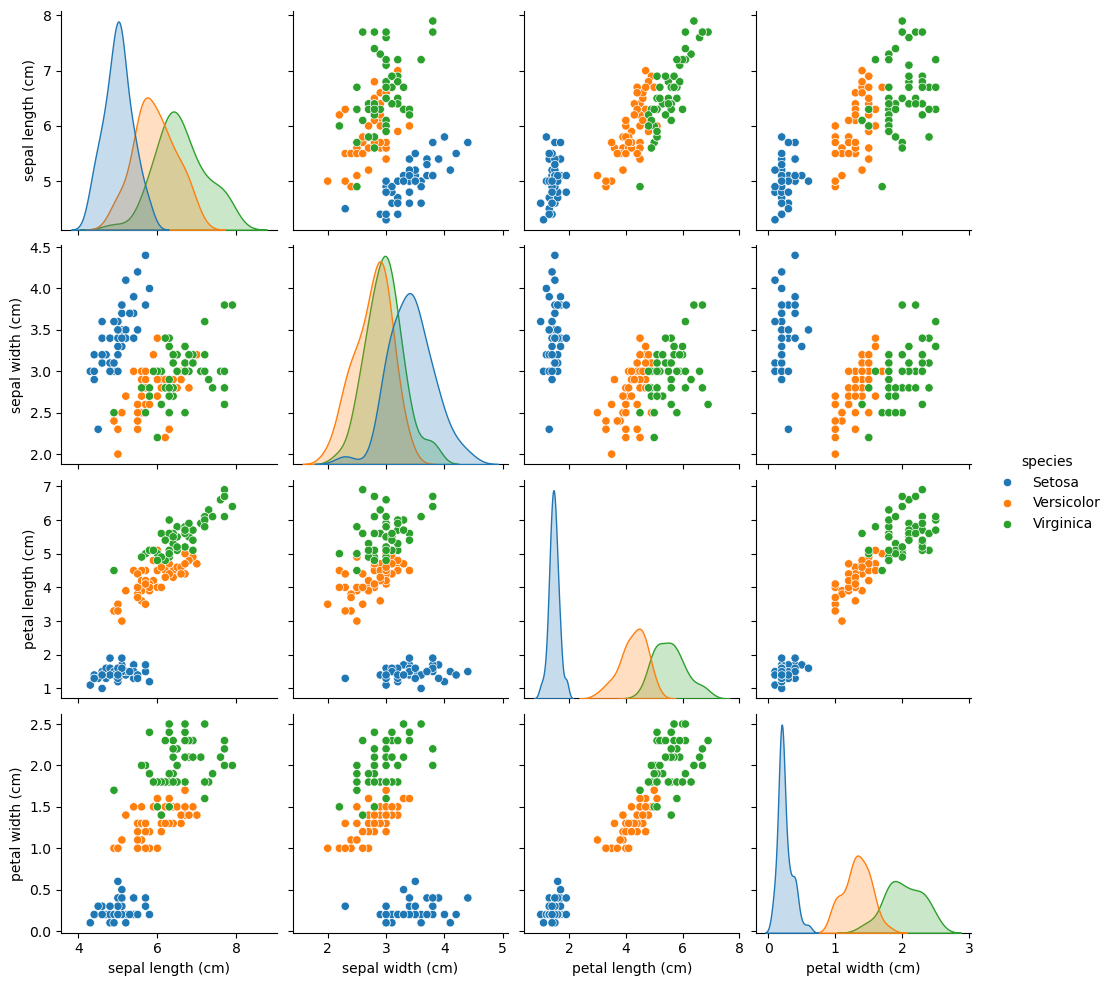

In [44]:
# Visualize relationships between the features for each species
sns.pairplot(df, hue="species")
plt.show()

### 5.1 Box Plot of Sepal Length

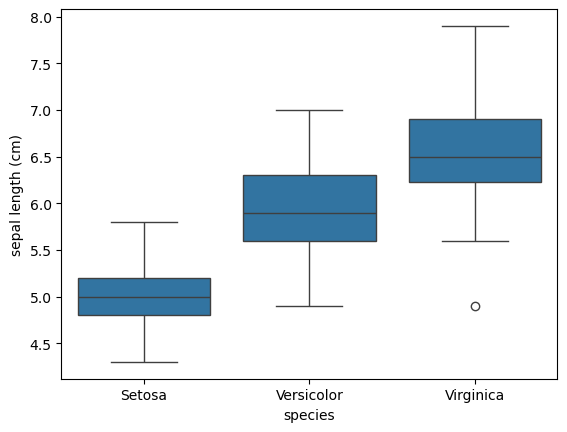

In [45]:
# Visualize the distribution of sepal length by species
sns.boxplot(x="species", y="sepal length (cm)", data=df)
plt.show()

### 5.2 Box Plot of Sepal Width

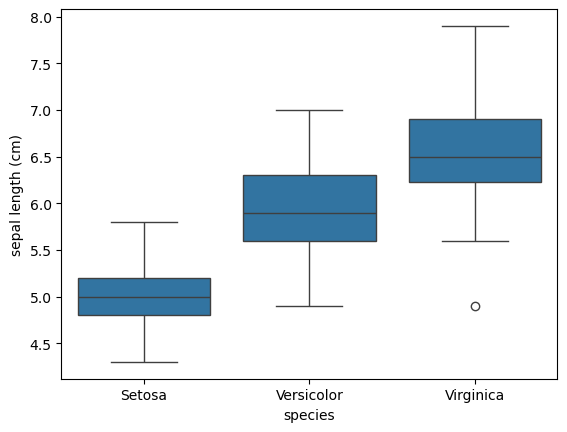

In [46]:
# Visualize the distribution of sepal length by species
sns.boxplot(x="species", y="sepal length (cm)", data=df)
plt.show()

### 5.3 Box Plot of Petal Length

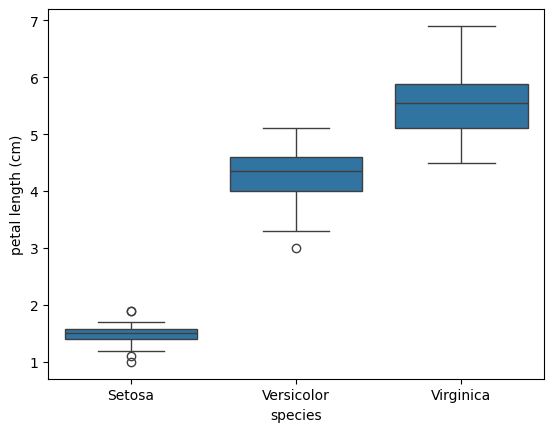

In [47]:
# Visualize the distribution of petal length by species
sns.boxplot(x="species", y="petal length (cm)", data=df)
plt.show()

### 5.4 Box Plot of Petal Width

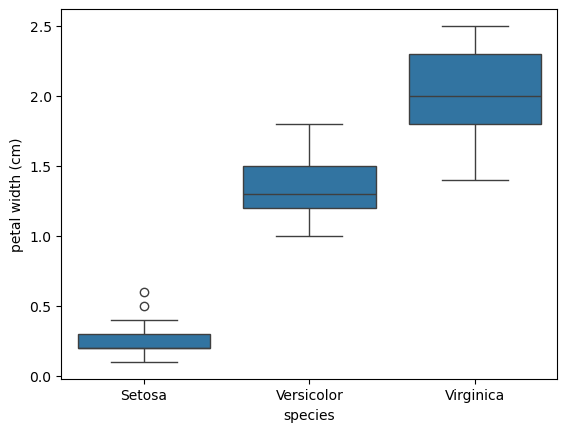

In [48]:
# Visualize the distribution of petal width by species
sns.boxplot(x="species", y="petal width (cm)", data=df)
plt.show()

## 6. Feature Selection

## Feature Selection

The Iris dataset contains four measurement features: sepal length, sepal width, petal length, and petal width.

From the visualizations, petal length and petal width appear to be the most discriminative features because they show clearer differences between the three iris species.

All four features will be used for training the classification models.

## 7. Prepare Features and Target

In [49]:
# Select the four measurements as input features
X = iris.data

# Select the species labels as the target
y = iris.target

## 8. Split the Dataset into Training and Testing Sets

In [50]:
# Split the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 9. Train Classification Models

In [22]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


### 9.1 Logistic Regression

In [51]:
# Create the Logistic Regression model
model1 = LogisticRegression(max_iter=200)

# Train the model using the training data
model1.fit(X_train, y_train)

# Predict species for the test data
y_pred1 = model1.predict(X_test)

# Calculate the model accuracy
accuracy1 = accuracy_score(y_test, y_pred1)

print("Logistic Regression Accuracy:", accuracy1)

Logistic Regression Accuracy: 1.0


### 9.2 K-Nearest Neighbors (KNN)

In [52]:
# Create the K-Nearest Neighbors model
model2 = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
model2.fit(X_train, y_train)

# Predict species for the test data
y_pred2 = model2.predict(X_test)

# Calculate the model accuracy
accuracy2 = accuracy_score(y_test, y_pred2)

print("KNN Accuracy:", accuracy2)

KNN Accuracy: 1.0


## 10. Compare Model Performance

In [53]:
# Compare the accuracy of both classification models
print("Model Comparison")
print("-----------------")
print("Logistic Regression Accuracy:", accuracy1)
print("KNN Accuracy:", accuracy2)

# Identify the model with the better accuracy
if accuracy1 > accuracy2:
    print("Best Model: Logistic Regression")
elif accuracy2 > accuracy1:
    print("Best Model: KNN")
else:
    print("Both models have the same accuracy")

Model Comparison
-----------------
Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0
Both models have the same accuracy


## 11. Confusion Matrix

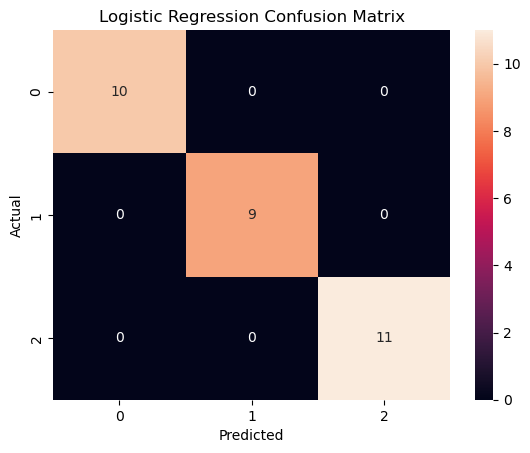

In [26]:
cm1 = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm1, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

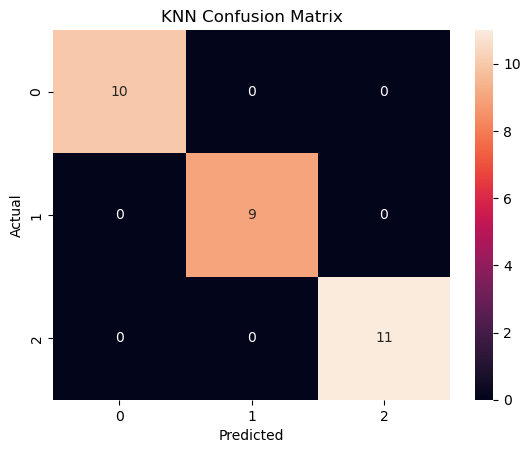

In [27]:
cm2 = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm2, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [28]:
print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    y_pred1,
    target_names=iris.target_names
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [29]:
print("KNN Classification Report")
print(classification_report(
    y_test,
    y_pred2,
    target_names=iris.target_names
))

KNN Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [30]:
print("Model Comparison")
print("-----------------")
print("Logistic Regression Accuracy:", accuracy1)
print("KNN Accuracy:", accuracy2)

if accuracy1 > accuracy2:
    print("Best Model: Logistic Regression")
elif accuracy2 > accuracy1:
    print("Best Model: KNN")
else:
    print("Both models have the same accuracy")

Model Comparison
-----------------
Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0
Both models have the same accuracy


## Conclusion

In this project, machine learning models were developed to classify iris flowers into three species: Setosa, Versicolor, and Virginica.

Two classification algorithms were trained:
- Logistic Regression
- K-Nearest Neighbors (KNN)

Both models achieved the same accuracy on the test dataset. The classification reports and confusion matrices also show strong classification performance.

Since both models performed equally well, both can be considered suitable for this Iris flower classification task.

## Best Model

Both Logistic Regression and K-Nearest Neighbors achieved the same accuracy on the test dataset.

Since both models performed equally well, there is no clear performance winner. Logistic Regression is selected as the preferred model because it provides the same predictive performance with a simple and interpretable approach.